# Week 8 Seminar.

## Chapter 8. Tree-based methods. ISLR textbook.

### Course: ML with Python, 2025/2026, HSE
### Author: Oleg Melnikov, Alexey Boldyrev, Teaching Team.

In this exercise we will build decision tree from scratch for the toy dataset and apply ready-to-use tree-based method for the Hitters dataset.


## Building your own decision tree
(the idea and code snippets are taken from [Josh Gordon's materials](https://github.com/random-forests/tutorials/blob/master/decision_tree.ipynb))

Let's build a tree which can predict type of domestic animal using it color and size as features.

In [1]:
# Numpy and Pandas. That's all we need.
import numpy as np, pandas as pd

This tiny dataset contain few records about domestic animals. Feel free to add your favorite pet to the dataset.

In [2]:
pets_data = [
  ['grey', 28, 'cat'],
  ['cream', 25, 'cat'],
  ['brown', 60, 'dog'],
  ['grey', 28, 'dog'],
  ['green', 17, 'parrot'],
  ['green', 12, 'turtle'],
]

columns = ['color', 'size (cm)', 'label']
pets = pd.DataFrame(pets_data, columns = columns)

Did you noticed the fact that the cat from 1st record and the dog from 4th record have the same color and size. How the tree can handle this case?

In [3]:
pets

,color,size (cm),label
0,grey,28,cat
1,cream,25,cat
2,brown,60,dog
3,grey,28,dog
4,green,17,parrot
5,green,12,turtle


We're able to select unique values both for quantitative (numeric) and categorical features:

In [4]:
def unique_vals(rows, col): return set([row[col] for row in rows])

In [5]:
unique_vals(pets_data, 1)

{12, 17, 25, 28, 60}

In [6]:
unique_vals(pets_data, 0)

{'brown', 'cream', 'green', 'grey'}

The function counts the number of each type of example in a dataset:

In [7]:
def class_counts(rows):
    counts = {}
    for row in rows:
        label = row[-1]
        if label not in counts:
            counts[label] = 0
        counts[label] += 1
    return counts

Now we can teach the code to ask some questions based on the feature name.

This simple function can do it:

In [8]:
def question(col, val):
  if not np.char.isnumeric(str(val)):
    condition = " == "
  else:
    condition = " >= "
  print("Is " + pets.columns[col] + condition + str(val) + "?")

In [9]:
question(1, 30)

Is size (cm) >= 30?


In [10]:
question(0, 'green')

Is color == green?


But to achieve the automotation, let's create a class which can handle the questions.

In [11]:
def is_numeric(value):
    """Test if a value is numeric."""
    return isinstance(value, int) or isinstance(value, float)

In [12]:
class Question:

    def __init__(self, column, value):
        self.column = column
        self.value = value

    def match(self, example):
        # Compare the feature value in an example to the
        # feature value in this question.
        val = example[self.column]
        if is_numeric(val):
            return val >= self.value
        else:
            return val == self.value

    def __repr__(self):
        # This is just a helper method to print
        # the question in a readable format.
        condition = "=="
        if is_numeric(self.value):
            condition = ">="
        return "Is %s %s %s?" % (
            columns[self.column], condition, str(self.value))

In [13]:
Question(1, 30)

Is size (cm) >= 30?

In [14]:
Question(0, 'green')

Is color == green?

We also able to match the question with the particular record:

In [15]:
q = Question(0, 'cream')

In [16]:
q.match(pets_data[0])

False

In [17]:
q.match(pets_data[1])

True

That's right. The 'cream' color is in the record with index 1:


In [18]:
pets

,color,size (cm),label
0,grey,28,cat
1,cream,25,cat
2,brown,60,dog
3,grey,28,dog
4,green,17,parrot
5,green,12,turtle


We will also need to count how many labels do we have:

In [19]:
print(pets.label.value_counts())

label
cat       2
dog       2
parrot    1
turtle    1
Name: count, dtype: int64


Let's define the partition. After asking the question above, we can split the dataset into *true_records* (in case of the positive answer) and *false_records* (for negative answer). Let's assign to the positive answer the case when the numerical value is equal or larger than value in the question and vice versa.

In [20]:
def partition(rows, question):
    """Partitions a dataset.

    For each row in the dataset, check if it matches the question. If
    so, add it to 'true rows', otherwise, add it to 'false rows'.
    """
    true_records, false_records = [], []
    for row in rows:
        if question.match(row):
            true_records.append(row)
        else:
            false_records.append(row)
    return true_records, false_records

Now we can easily select the records labelled as 'dog' among the pets:

In [21]:
true_records, false_records = partition(pets_data, Question(2, 'dog'))
# true_records, false_records = partition(pets_data, Question(1, 27))
# true_records, false_records = partition(pets_data, Question(0, 'green'))

true_records

[['brown', 60, 'dog'], ['grey', 28, 'dog']]

... or the records which are not associated with the dogs:

In [22]:
false_records

[['grey', 28, 'cat'],
 ['cream', 25, 'cat'],
 ['green', 17, 'parrot'],
 ['green', 12, 'turtle']]

When building a classification tree, the Gini index (as well as entropy and other measures) is typically used to evaluate the quality of a particular split. The Gini Impurity coefficient for $i$ the subset:

$$G_i = \sum_{k=1}^K \hat{p}_{i,k}(1 - \hat{p}_{i,k}) = \sum_{k=1}^K \hat{p}_{i,k} - \sum_{k=1}^K \hat{p}_{i,k}^2 = 1 - \sum_{k=1}^K \hat{p}_{i,k}^2$$

In [23]:
def gini(rows):
    counts = class_counts(rows)
    impurity = 1
    for lbl in counts:
        prob_of_lbl = counts[lbl] / float(len(rows))
        impurity -= prob_of_lbl**2
    return impurity

Let's look at some example to understand how Gini Impurity works. First, we'll look at a dataset with no mixing:

In [24]:
no_mixing = [['cat'],
              ['cat']]

gini(no_mixing)

0.0

In [25]:
class_counts(no_mixing)

{'cat': 2}

In [26]:
gini([['triangle'],
             ['triangle'],
             ['triangle'],
              ['circle']])

0.375

In [27]:
1/4 * 3/4 + 3/4 * 1/4

0.375

Now, we'll look at dataset with a 50/50 cats/dogs ratio:

In [28]:
some_mixing = [['cat'],['cat'], ['dog'], ['dog']]
gini(some_mixing)

0.5

In [29]:
class_counts(some_mixing)

{'cat': 2, 'dog': 2}

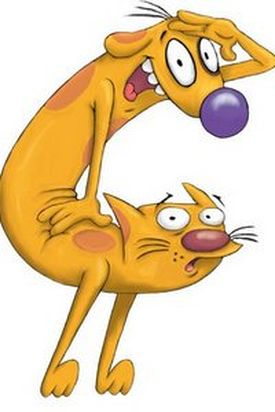

CatDog TV series created by Peter Hannan for Nickelodeon (unknown artist, [image source](https://www.pinterest.com/pin/495325659015162222/))

Now, we'll look at a dataset with many different labels:

In [30]:
lots_of_mixing = [['cat'],
                  ['dog'],
                  ['hamster'],
                  ['guinea pig'],
                  ['chameleon']]

gini(lots_of_mixing)

0.7999999999999998

Let's define the information gain as the uncertainty of the starting node, minus the weighted impurity of two child nodes.

In [31]:
def info_gain(left, right, current_uncertainty):
    p = float(len(left)) / (len(left) + len(right))
    return current_uncertainty - p * gini(left) - (1 - p) * gini(right)

Calculate the uncertainy of our training data.

In [32]:
current_uncertainty = gini(pets_data)
current_uncertainty

0.7222222222222221

How much information do we gain by partioning on size = 15?

In [33]:
true_records, false_records = partition(pets_data, Question(1, 15))
info_gain(true_records, false_records, current_uncertainty)

0.18888888888888877

... by partioning on size = 25?

In [34]:
true_records, false_records = partition(pets_data, Question(1, 25))
info_gain(true_records, false_records, current_uncertainty)

0.2222222222222221

... by partioning on size = 30?

In [35]:
true_records, false_records = partition(pets_data, Question(1, 30))
info_gain(true_records, false_records, current_uncertainty)

0.12222222222222223

In [36]:
pets_data

[['grey', 28, 'cat'],
 ['cream', 25, 'cat'],
 ['brown', 60, 'dog'],
 ['grey', 28, 'dog'],
 ['green', 17, 'parrot'],
 ['green', 12, 'turtle']]

# Exercise:
Why we learned more when partitioning using size = 25?
Look at the different splits that result, and see which one looks more 'unmixed' to you.

Let's find the best question to ask by iterating over every feature and value and сalculating the information gain.

In [37]:
def find_best_split(rows):
    """Find the best question to ask by iterating over every feature / value
    and calculating the information gain."""
    best_gain = 0  # keep track of the best information gain
    best_question = None  # keep train of the feature / value that produced it
    current_uncertainty = gini(rows)
    n_features = len(rows[0]) - 1  # number of columns

    for col in range(n_features):  # for each feature

        values = set([row[col] for row in rows])  # unique values in the column

        for val in values:  # for each value

            question = Question(col, val)

            # try splitting the dataset
            true_rows, false_rows = partition(rows, question)

            # Skip this split if it doesn't divide the
            # dataset.
            if len(true_rows) == 0 or len(false_rows) == 0:
                continue

            # Calculate the information gain from this split
            gain = info_gain(true_rows, false_rows, current_uncertainty)

            # You actually can use '>' instead of '>=' here
            # but I wanted the tree to look a certain way for our
            # toy dataset.
            if gain >= best_gain:
                best_gain, best_question = gain, question

    return best_gain, best_question

Find the best question to ask first for our dataset.


In [38]:
best_gain, best_question = find_best_split(pets_data)
best_question

Is size (cm) >= 25?

Bingo!

The algorithm confirmed that partitioning using size = 25 is the best.

Let's write few more classes and functions to handle the tree in more comfortable way:

In [39]:
class Leaf:

    def __init__(self, rows):
      self.predictions = class_counts(rows)

In [40]:
class Decision_Node:

    def __init__(self,
                 question,
                 true_branch,
                 false_branch):
        self.question = question
        self.true_branch = true_branch
        self.false_branch = false_branch

This function splits the dataset on each of the unique feature, calculates the information gain and return the question node (the best feature/value to ask).

In [41]:
def build_tree(rows):
    gain, question = find_best_split(rows)
    if gain == 0: return Leaf(rows)
    true_rows, false_rows = partition(rows, question)

    true_branch = build_tree(true_rows)
    false_branch = build_tree(false_rows)
    return Decision_Node(question, true_branch, false_branch)

This function is a helper to produce human-readable outputs (both for the questions and the predictions).

In [42]:
def print_tree(node, spacing=""):
    """World's most elegant tree printing function."""

    # Base case: we've reached a leaf
    if isinstance(node, Leaf):
        print (spacing + "Predict", node.predictions)
        return

    # Print the question at this node
    print (spacing + str(node.question))

    # Call this function recursively on the true branch
    print (spacing + '--> True:')
    print_tree(node.true_branch, spacing + "  ")

    # Call this function recursively on the false branch
    print (spacing + '--> False:')
    print_tree(node.false_branch, spacing + "  ")

In [43]:
my_tree = build_tree(pets_data)

In [44]:
print_tree(my_tree)

Is size (cm) >= 25?
--> True:
  Is size (cm) >= 28?
  --> True:
    Is color == grey?
    --> True:
      Predict {'cat': 1, 'dog': 1}
    --> False:
      Predict {'dog': 1}
  --> False:
    Predict {'cat': 1}
--> False:
  Is size (cm) >= 17?
  --> True:
    Predict {'parrot': 1}
  --> False:
    Predict {'turtle': 1}


In [45]:
def classify(row, node):
    """See the 'rules of recursion' above."""

    # Base case: we've reached a leaf
    if isinstance(node, Leaf):
        return node.predictions

    # Decide whether to follow the true-branch or the false-branch.
    # Compare the feature / value stored in the node,
    # to the example we're considering.
    if node.question.match(row):
        return classify(row, node.true_branch)
    else:
        return classify(row, node.false_branch)

In [46]:
#######
# Demo:
# The tree predicts the 2nd row of our
# training data is an apple with confidence 1.
classify(pets_data[0], my_tree)
#######

{'cat': 1, 'dog': 1}

In [47]:
def print_leaf(counts):
    """A nicer way to print the predictions at a leaf."""
    total = sum(counts.values()) * 1.0
    probs = {}
    for lbl in counts.keys():
        probs[lbl] = str(int(counts[lbl] / total * 100)) + "%"
    return probs

In [48]:
#######
# Demo:
# Printing that a bit nicer
print_leaf(classify(pets_data[0], my_tree))
#######

{'cat': '50%', 'dog': '50%'}

In [49]:
#######
# Demo:
# On the second example, the confidence is lower
print_leaf(classify(pets_data[4], my_tree))
#######

{'parrot': '100%'}

Let's try to evaluate the tree on the following dataset:

In [50]:
# Evaluate on
domestic_animals = [
  ['brown', 35, 'cat'],
  ['grey', 20, 'cat'],
  ['cream', 26, 'cat'],
  ['grey', 70, 'dog'],
  ['white', 50, 'parrot'],
  ['albino', 10, 'turtle'],
]

In [51]:
for row in domestic_animals:
    print ("Actual: %s. Predicted: %s" %
           (row[-1], print_leaf(classify(row, my_tree))))

Actual: cat. Predicted: {'dog': '100%'}
Actual: cat. Predicted: {'parrot': '100%'}
Actual: cat. Predicted: {'cat': '100%'}
Actual: dog. Predicted: {'cat': '50%', 'dog': '50%'}
Actual: parrot. Predicted: {'dog': '100%'}
Actual: turtle. Predicted: {'turtle': '100%'}


The results of the classification are not excellent.

# Exercise
Try to add more features & examples to 'pets' and evaluate the tree on the extended 'domestic_animals' dataset.

In [52]:
header = ['color', 'size', 'extra feature', 'label']

pets = [
  ['grey', 28, '...', 'cat'],
  ['cream', 25, '...', 'cat'],
  ['brown', 60, '...', 'dog'],
  ['grey', 28, '...', 'dog'],
  ['green', 17, '...', 'parrot'],
  ['green', 12, '...', 'turtle'],
]

domestic_animals = [
  ['grey', 28, '...', 'cat'],
  ['cream', 25, '...', 'cat'],
  ['brown', 60, '...', 'dog'],
  ['grey', 28, '...', 'dog'],
  ['green', 17, '...', 'parrot'],
  ['green', 12, '...', 'turtle'],
]

In [53]:
my_tree = build_tree(pets)

In [54]:
print_tree(my_tree)

Is size (cm) >= 25?
--> True:
  Is size (cm) >= 28?
  --> True:
    Is color == grey?
    --> True:
      Predict {'cat': 1, 'dog': 1}
    --> False:
      Predict {'dog': 1}
  --> False:
    Predict {'cat': 1}
--> False:
  Is size (cm) >= 17?
  --> True:
    Predict {'parrot': 1}
  --> False:
    Predict {'turtle': 1}


In [55]:
for row in domestic_animals:
    print ("Actual: %s. Predicted: %s" %
           (row[-1], print_leaf(classify(row, my_tree))))

Actual: cat. Predicted: {'cat': '50%', 'dog': '50%'}
Actual: cat. Predicted: {'cat': '100%'}
Actual: dog. Predicted: {'dog': '100%'}
Actual: dog. Predicted: {'cat': '50%', 'dog': '50%'}
Actual: parrot. Predicted: {'parrot': '100%'}
Actual: turtle. Predicted: {'turtle': '100%'}


# Classification And Regression (decision) Trees (CART)
In this part of the seminar we will review the [*Hitters.csv* data set](https://rdrr.io/cran/ISLR/man/Hitters.html) and build a [decision tree (DT) model from the Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor) to **predict salaries** of the Baseball players. A data frame with 322 observations of major league players (one row per player) on the following 20 variables, which are mostly counters.

1. AtBat: # of times at bat in 1986
1. Hits: # of hits in 1986
1. HmRun: # of home runs in 1986
1. Runs: # of runs in 1986
1. RBI: # of runs batted in in 1986
1. Walks: # of walks in 1986
1. Years: # of years in the major leagues
1. CAtBat: # of times at bat during his career
1. CHits: # of hits during his career
1. CHmRun: # of home runs during his career
1. CRuns: # of runs during his career
1. CRBI: # of runs batted in during his career
1. CWalks: # of walks during his career
1. League: a factor with levels `A` and `N` indicating player's league at the end of 1986
1. Division: a factor with levels `E` and `W` indicating player's division at the end of 1986
1. PutOuts: # of put outs in 1986
1. Assists: # of assists in 1986
1. Errors: # of errors in 1986
1. Salary: 1987 annual salary on opening day in thousands of dollars
1. NewLeague: a factor with levels `A` and `N` indicating player's league at the beginning of 1987

<font color=gray>
    
## Part 1. Describe Your Data

In [56]:
import pandas as pd, numpy as np, seaborn as sns, sklearn,matplotlib.pyplot as plt
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"   # enables multiple outputs from a single cell
pd.set_option('display.max_rows', 6)
plt.rcParams['figure.figsize'] = [18, 4]

df = pd.read_csv('https://raw.githubusercontent.com/omelnikov/data/main/hitters/Hitters.csv')
df = df.rename(columns={'Unnamed: 0':'name'})
df  # Evaluate values, units, data types, anything unusual

,PlayerName,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,Wayne Tolleson,475,126,3,61,43,52,6,1700,433,...,217,93,146,A,W,37,113,7,385.0,A
320,Willie Upshaw,573,144,9,85,60,78,8,3198,857,...,470,420,332,A,E,1314,131,12,960.0,A
321,Willie Wilson,631,170,9,77,44,31,11,4908,1457,...,775,357,249,A,W,408,4,3,1000.0,A


Evaluate the structure of every column in a dataframe.

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PlayerName  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

In [58]:
pd.set_option('display.max_rows', 100)

# Select only numeric columns to avoid issues with non-numeric data
numeric_df = df.select_dtypes(include=[float, int])

# Compute basic statistics and drop 'count' row
dfStats = numeric_df.describe().drop('count', axis=0)

# Calculate Interquartile Range (IQR)
dfStats.loc['IQR'] = dfStats.loc['75%'] - dfStats.loc['25%']

# Calculate skewness, mean absolute deviation (mad), and kurtosis
extra_stats = numeric_df.agg(['skew', lambda x: (x - x.mean()).abs().mean(), 'kurt'])
extra_stats.index = ['skew', 'mad', 'kurt']  # Rename index properly for mad

# # Reindex columns of extra_stats to align with dfStats and concatenate
extra_stats = extra_stats.reindex(dfStats.columns, axis=1)
dfStats = pd.concat([dfStats, extra_stats])

# Round the results to 2 decimal places
dfStats.round(2)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
mean,380.93,101.02,10.77,50.91,48.03,38.74,7.44,2648.68,717.57,69.49,358.80,330.12,260.24,288.94,106.91,8.04,535.93
std,153.40,46.45,8.71,26.02,26.17,21.64,4.93,2324.21,654.47,86.27,334.11,333.22,267.06,280.70,136.85,6.37,451.12
min,16.00,1.00,0.00,0.00,0.00,0.00,1.00,19.00,4.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,67.50
25%,255.25,64.00,4.00,30.25,28.00,22.00,4.00,816.75,209.00,14.00,100.25,88.75,67.25,109.25,7.00,3.00,190.00
50%,379.50,96.00,8.00,48.00,44.00,35.00,6.00,1928.00,508.00,37.50,247.00,220.50,170.50,212.00,39.50,6.00,425.00
75%,512.00,137.00,16.00,69.00,64.75,53.00,11.00,3924.25,1059.25,90.00,526.25,426.25,339.25,325.00,166.00,11.00,750.00
max,687.00,238.00,40.00,130.00,121.00,105.00,24.00,14053.00,4256.00,548.00,2165.00,1659.00,1566.00,1378.00,492.00,32.00,2460.00
IQR,256.75,73.00,12.00,38.75,36.75,31.00,7.00,3107.50,850.25,76.00,426.00,337.50,272.00,215.75,159.00,8.00,560.00
skew,-0.08,0.29,0.90,0.42,0.61,0.62,0.78,1.23,1.36,2.16,1.39,1.53,1.75,2.06,1.36,1.06,1.59
mad,131.86,38.89,7.15,21.71,21.23,17.72,4.08,1862.96,520.58,61.33,264.38,250.85,200.02,189.12,109.73,5.04,343.62


In [59]:
# # SOLUTION
# pd.set_option('display.max_rows', 100)
# dfStats = df.describe().drop('count', axis=0)
# dfStats.loc['IQR'] = dfStats.loc['75%'] - dfStats.loc['25%'] # appending interquartile range instead of recalculating it
# dfStats = dfStats.append(df.reindex(dfStats.columns, axis=1).agg(['skew', 'mad', 'kurt']))
# dfStats.round(2)

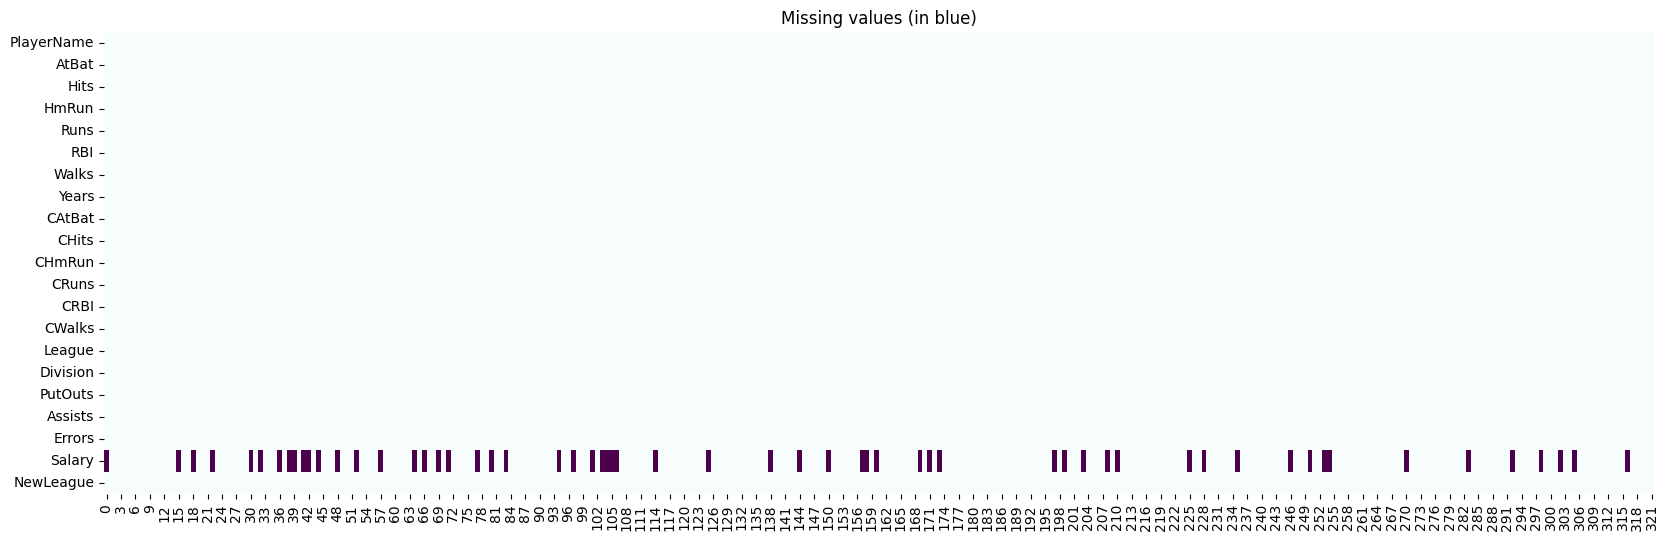

In [60]:
# Plot-smart! Stretch your plot horizontally, rotate as needed. Avoid overplotting. Plots talk!
plt.rcParams['figure.figsize'] = [20, 6]
ax = sns.heatmap(df.isnull().T, cmap = "BuPu", cbar=False);
ax.set_title('Missing values (in blue)');

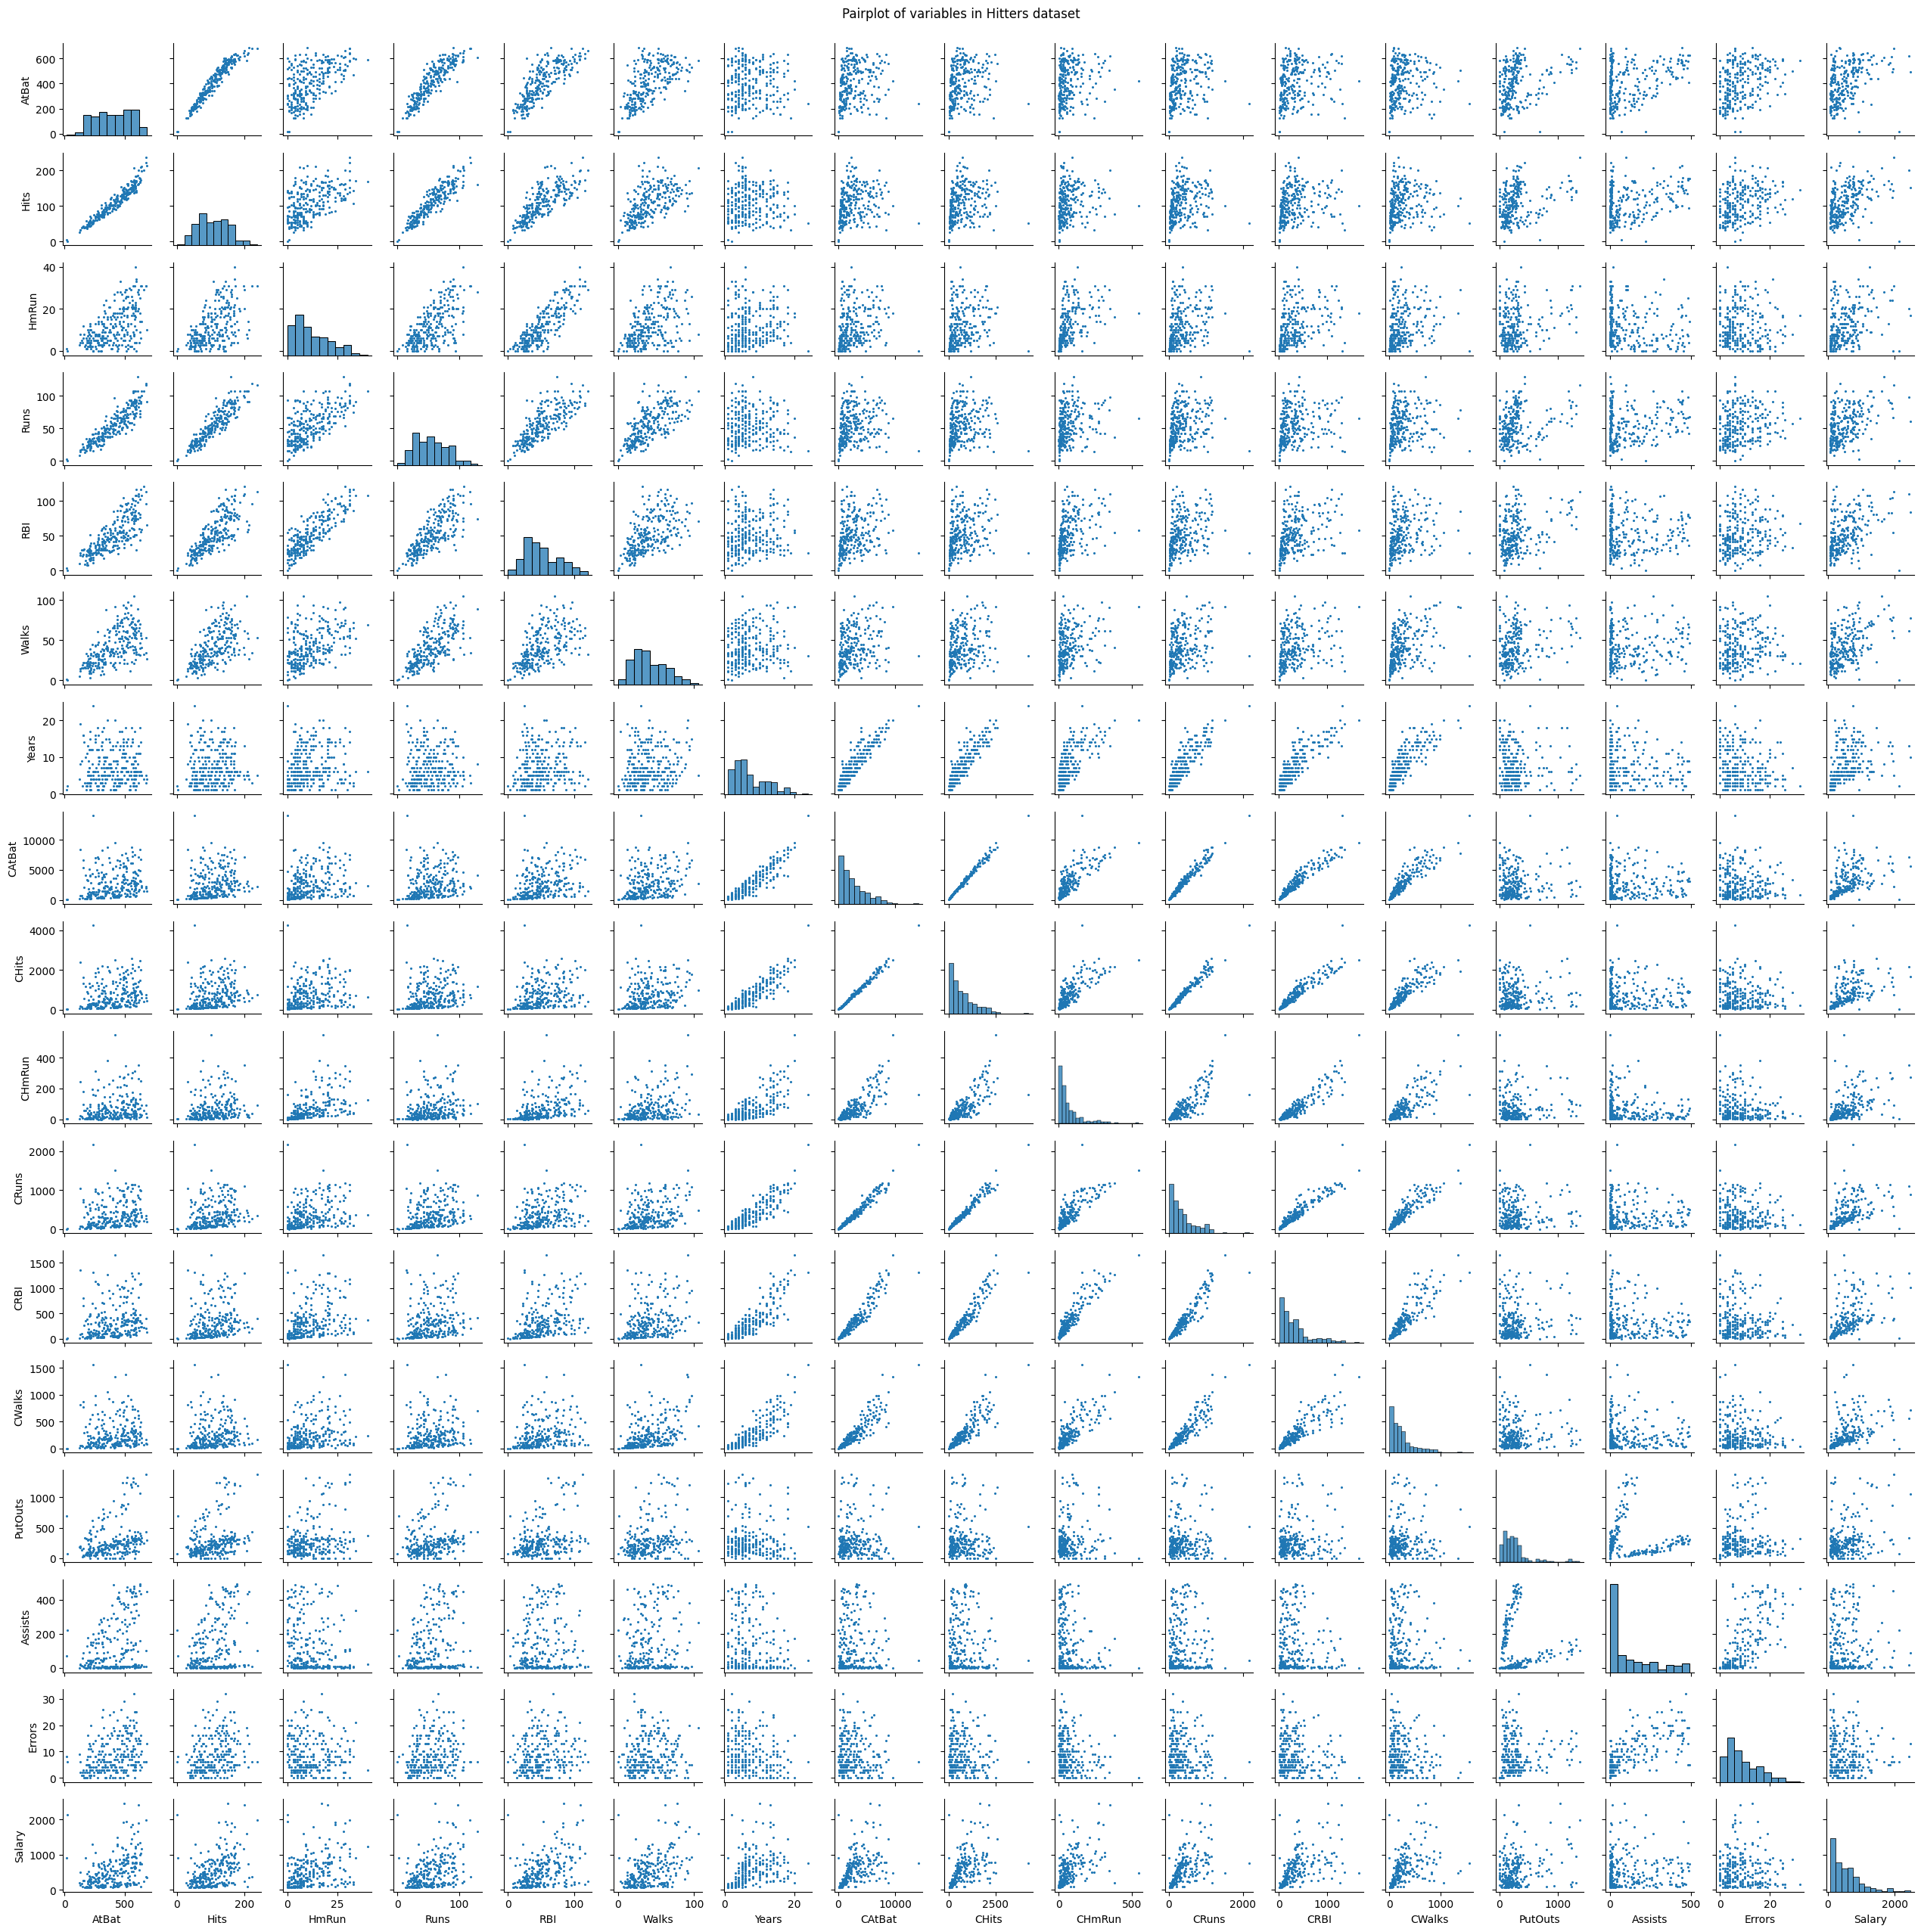

In [61]:
ax = sns.pairplot(df.loc[~ df.Salary.isna(),], plot_kws=dict(linewidth=0, s=5), height=1.5);
ax.fig.suptitle("Pairplot of variables in Hitters dataset", y=1);
plt.tight_layout();
plt.show();


# Baseline model, v0
Since we need to build a model to predict the `Salary` variable, the missing values in `Salary` are not helpful for either training or evaluation. Let's remove these for now. Alternatively, we could just fill NA's with zeros using `df.fillna(0)`

In [62]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

df = df.loc[~ df.Salary.isna(),]     # keep rows where salary values are not NaN.
X = df._get_numeric_data().drop('Salary', axis=1)
Y = df['Salary']
tX, vX, tY, vY = train_test_split(X, Y, test_size=0.2, random_state=0)

For regression analysis, the common suitable metrics are $R^2=1-SSR/SST$, MSE, RMSE (=$\sqrt{MSE}$). These are [all related](https://stats.stackexchange.com/questions/214886/regression-what-is-the-utility-of-r-squared-compared-to-rmse) in some sense. $R^2$ is a easier to itnerpret because it is normalized to be in [0,1] (but can be negative if SSR>>SST). Note: For regression models, do *not* use classification metrics, such as accuracy, precision, recall, $F_1$, etc.

DecisionTreeRegressor(random_state=0)

,Pred Salary (train),Actual Salary (train),Pred Salary (val),Actual Salary (val)
0,130.000,130.000,100.0,640.0
1,1350.000,1350.000,587.5,487.5
2,1041.667,1041.667,210.0,185.0
3,145.000,145.000,1050.0,1100.0
4,750.000,750.000,135.0,202.5


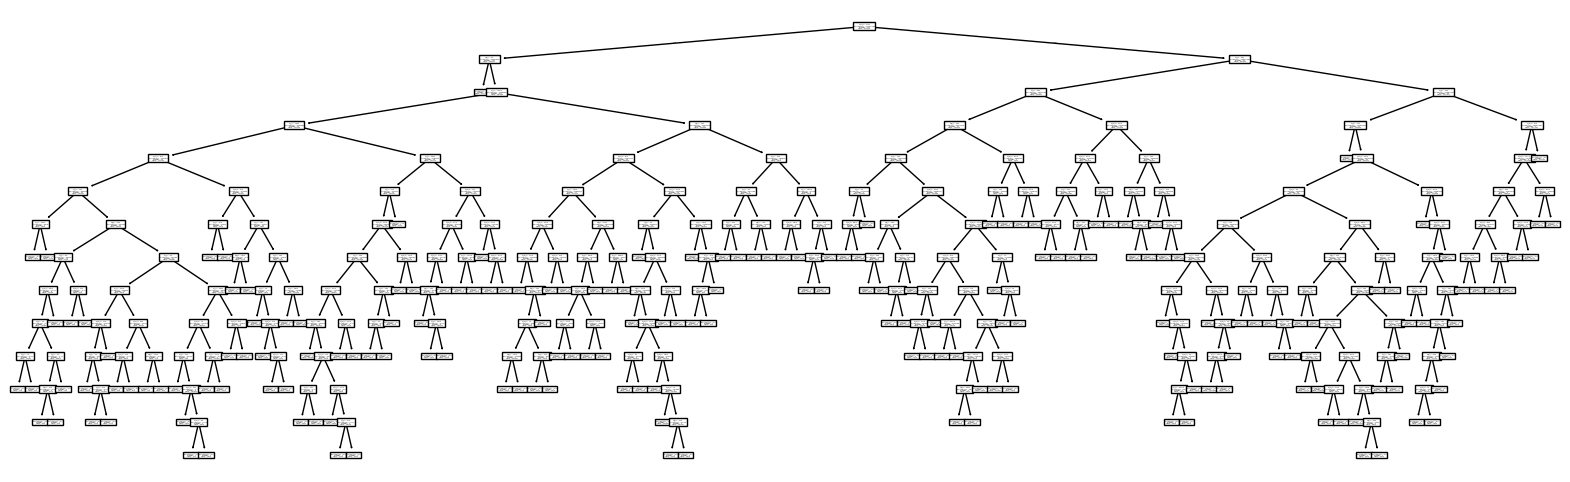

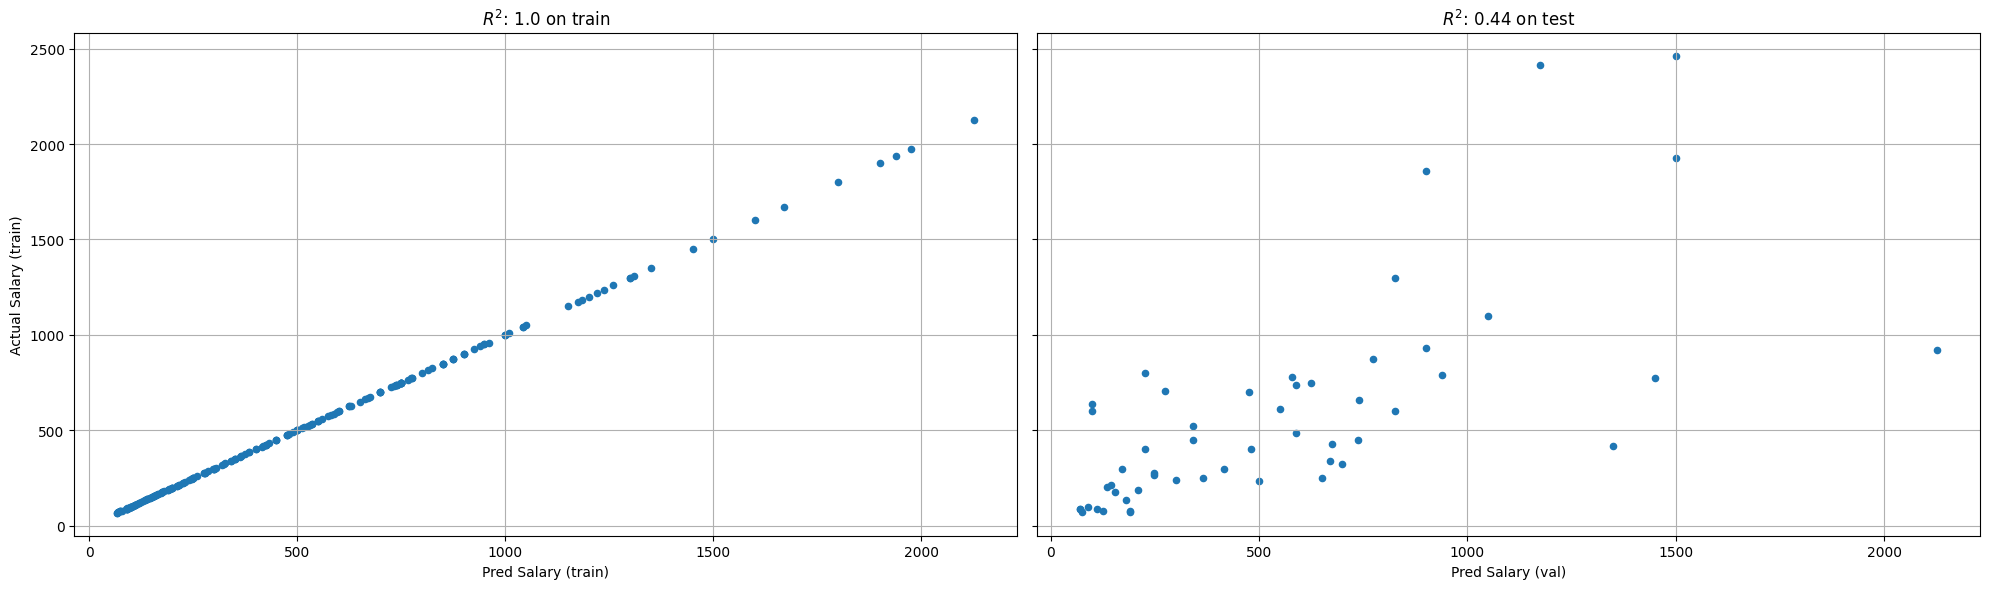

In [63]:
from sklearn.metrics import r2_score
v0 = DecisionTreeRegressor(random_state=0)     # decision tree baseline model
v0.fit(tX, tY)

tmp = sklearn.tree.plot_tree(v0);
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
dfT = pd.DataFrame([v0.predict(tX), tY], index=['Pred Salary (train)', 'Actual Salary (train)']).T
dfV = pd.DataFrame([v0.predict(vX), vY], index=['Pred Salary (val)',   'Actual Salary (val)']).T
pd.concat([dfT.head(), dfV.head()], axis=1)
a = dfT.plot.scatter(0,1, grid=True, ax=ax1, title=f'$R^2$: {v0.score(tX, tY)} on train')   # in-sample predictions
a = dfV.plot.scatter(0,1, grid=True, ax=ax2, title=f'$R^2$: {v0.score(vX, vY):0.2f} on test')   # out-of-sample predictions
plt.tight_layout()

We see perfect fit on train and a poor fit on test data (R^2 = 44%)

# Let's tune hyperparameters
We can evaluate this model at different values of `max_depth` hyperparameter and pick the best one.

DecisionTreeRegressor(max_depth=5, random_state=0)


R^2: 0.87 on train, 0.48 on test


,Pred Salary (train),Actual Salary (train),Pred Salary (val),Actual Salary (val)
0,103.696970,130.000,325.208375,640.0
1,1388.750000,1350.000,1004.722200,487.5
2,1004.722200,1041.667,177.916667,185.0
3,152.666667,145.000,937.500000,1100.0
4,716.666667,750.000,152.666667,202.5


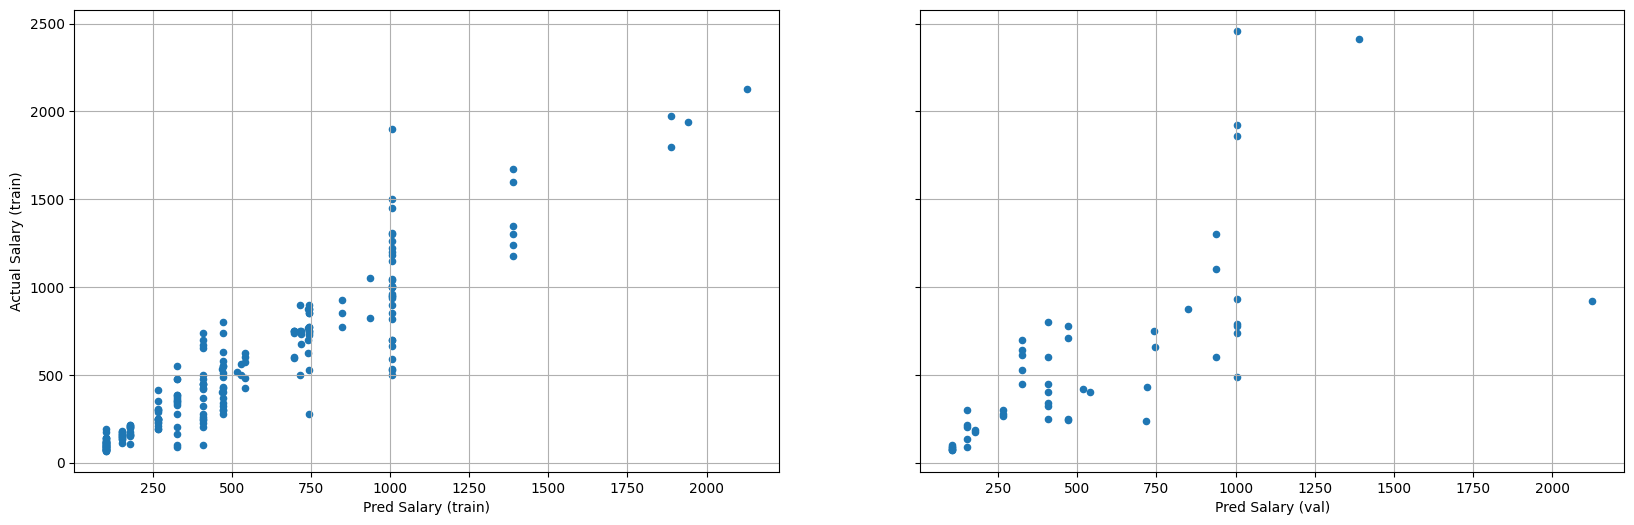

In [64]:
m = DecisionTreeRegressor(random_state=0, max_depth=5)     # baseline model
m.fit(tX, tY)
print(f'\nR^2: {m.score(tX, tY):.2f} on train, {m.score(vX, vY):.2f} on test')   # a strong learner will overfit, if not constrained
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
dfT = pd.DataFrame([m.predict(tX), tY], index=['Pred Salary (train)','Actual Salary (train)']).T
dfV = pd.DataFrame([m.predict(vX), vY], index=['Pred Salary (val)','Actual Salary (val)']).T
pd.concat([dfT.head(),dfV.head()], axis=1)
a = dfT.plot.scatter(0,1, grid=True, ax=ax1)   # Predictions on train set
a = dfV.plot.scatter(0,1, grid=True, ax=ax2)   #  Predictions on validation set

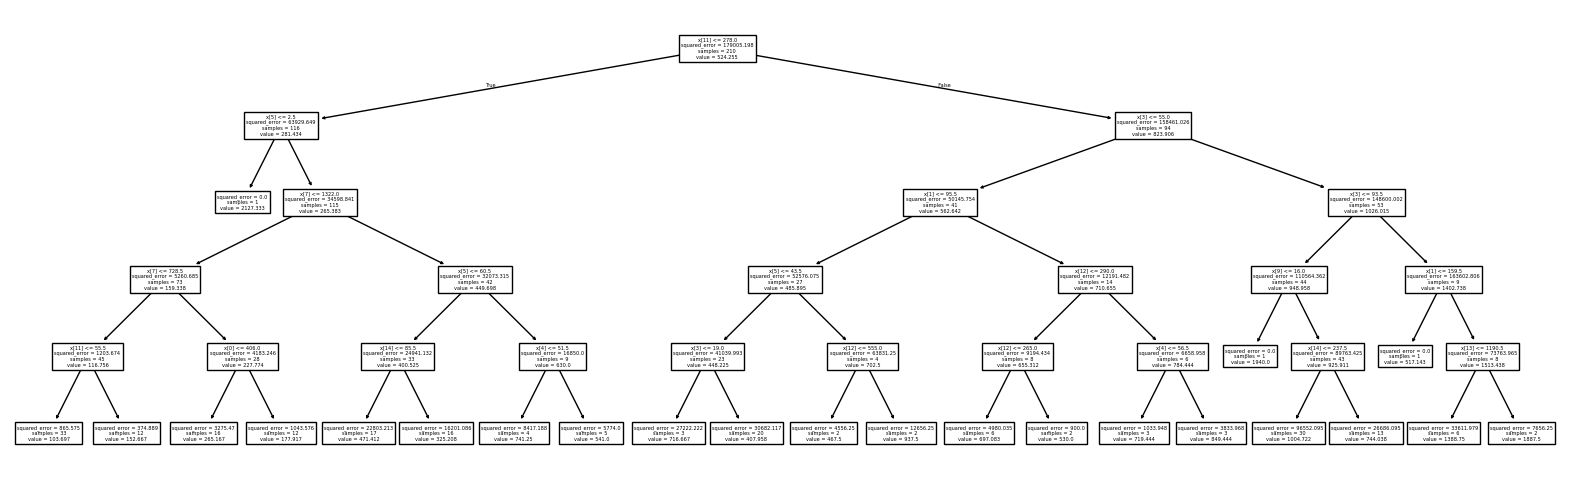

In [65]:
tmp = sklearn.tree.plot_tree(m);

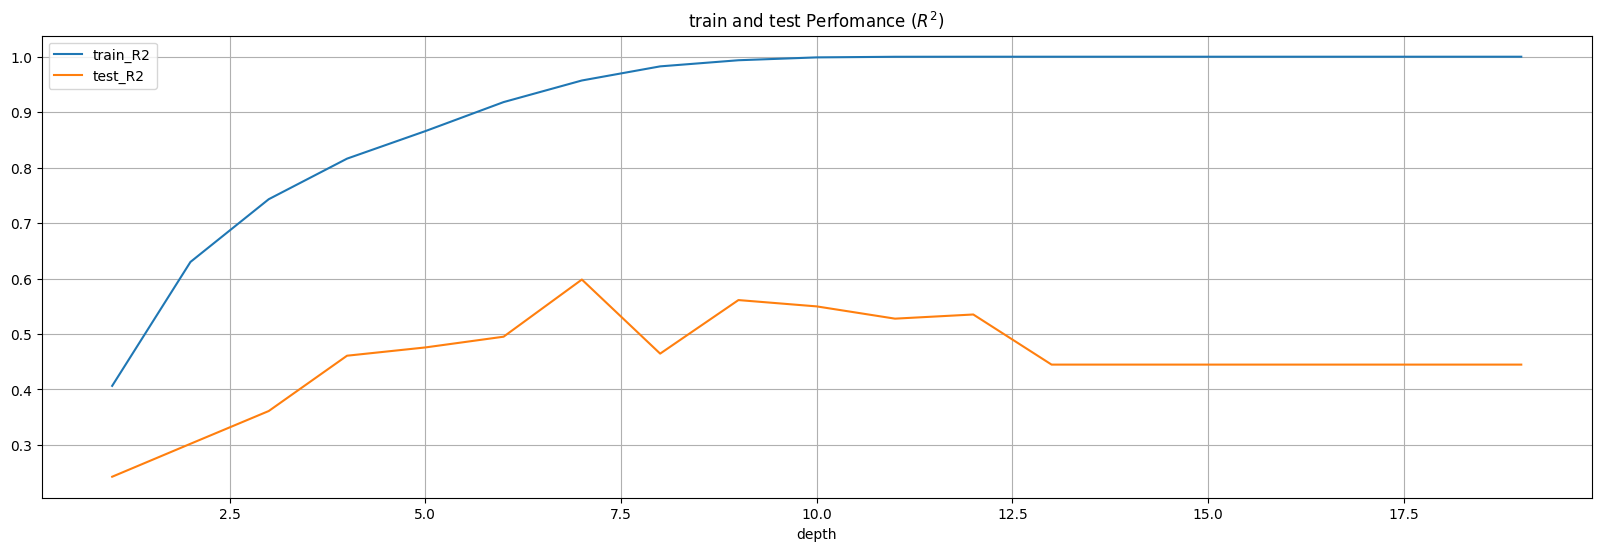

In [66]:
res = []   #result
m = DecisionTreeRegressor(random_state=0)     # baseline model
for i in range(1,20):
    a = m.set_params(max_depth=i).fit(tX, tY)
    res.append((i, m.score(tX, tY), m.score(vX, vY)))
dfRes = pd.DataFrame(res, columns=['depth','train_R2','test_R2']).set_index('depth')
a = dfRes.plot(grid=True, title='train and test Perfomance ($R^2$)')
# ?dt.score

While train performance keeps increasing with depth, the test performance deteriorates after depth of 10-12. This is also dependent on other factors such as seed.

Cross validation (CV) allows us to re-use all data in estimating optimal parameter values.

/tmp/ipython-input-2408490262.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  a = cvR2.plot(grid=True, title=f'Avg (valdiation) $R^2$ is {float(cvR2.mean()):.2f} from 10-CV', kind='bar')
/tmp/ipython-input-2408490262.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  a = plt.axhline(float(cvR2.mean()), color='r', linestyle='dashed', linewidth=1)


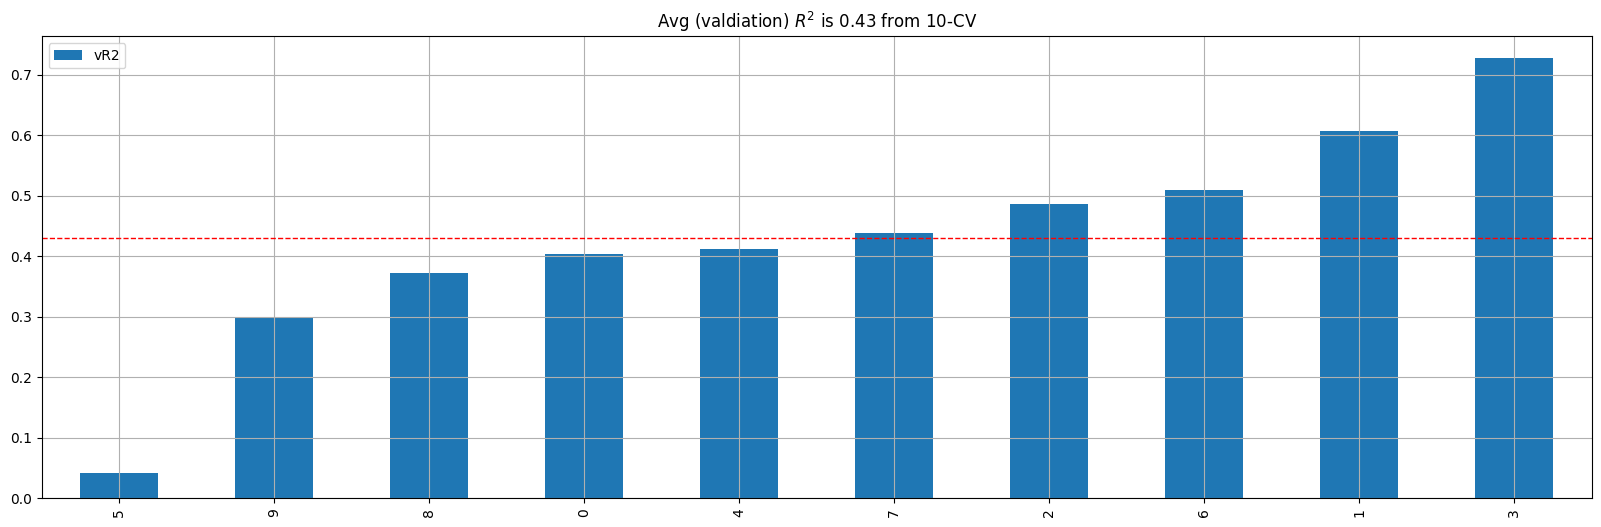

In [67]:
m = DecisionTreeRegressor(random_state=0, max_depth=3)
cvR2 = pd.DataFrame(cross_val_score(m, X, Y, cv=10), columns=['vR2']).sort_values('vR2')  # default:  scoring=('r2')
a = cvR2.plot(grid=True, title=f'Avg (valdiation) $R^2$ is {float(cvR2.mean()):.2f} from 10-CV', kind='bar')
a = plt.axhline(float(cvR2.mean()), color='r', linestyle='dashed', linewidth=1)

We can visualize a particular tree.

In [68]:
from sklearn.tree import export_graphviz
import os, graphviz,pydotplus
os.environ["PATH"] += os.pathsep + 'C:/Program Files (x86)/Graphviz2.38/bin/'

DecisionTreeRegressor(min_samples_leaf=10, random_state=0)

True

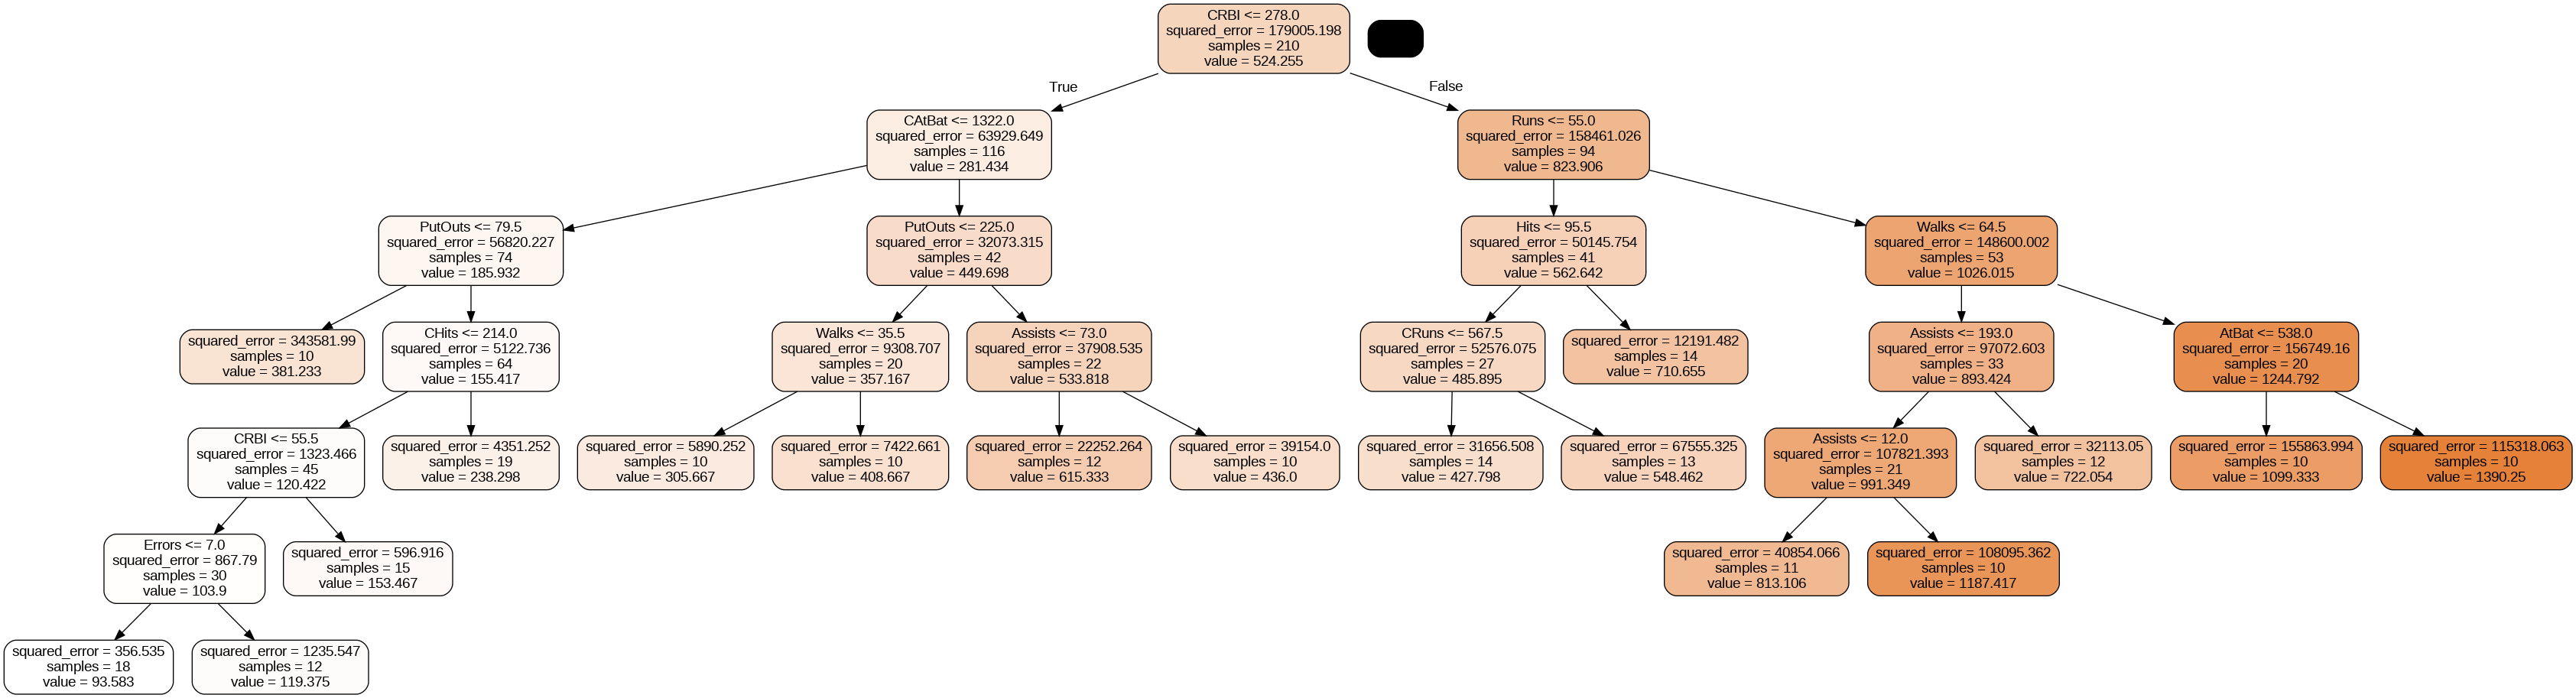

In [69]:
m = DecisionTreeRegressor(random_state=0, min_samples_leaf=10)
m.fit(tX,tY)
# dot_data = export_graphviz(m, filled=True, rounded=True, feature_names=X.columns, out_file=None)
# dot_data.set_size('"5,5!"')
# graphviz.Source(dot_data, ratio="compress")   # need to install graphviz.gitlab.io

dot_data = export_graphviz(m, filled=True, rounded=True, feature_names=X.columns, out_file=None)
pydot_graph = pydotplus.graph_from_dot_data(dot_data)
# pydot_graph.set_size('"30,30!"')
pydot_graph.write_png('resized_tree.png')
from IPython.display import Image
Image("resized_tree.png")